# Laboratorio #2 - Redes Neuronales Convolucionales (CNN)

**Curso:** CC3092 - Deep Learning y Sistemas Inteligentes

**Dataset:** MNIST (torchvision.datasets.MNIST) - clasificacion multiclase de digitos manuscritos (0-9)

**Repositorio:** _(pendiente de completar)_

Este notebook contiene: carga y preparacion de datos, investigacion de capas de PyTorch para CNN, definicion de las arquitecturas MLP y CNN, busqueda de hiperparametros (6 iteraciones por arquitectura), y evaluacion final sobre el conjunto de test.


## 1. Importacion de librerias y carga del dataset

In [1]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader

from torchvision import datasets, transforms

from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("torch:", torch.__version__)
print("CUDA disponible:", torch.cuda.is_available())
print("Device:", DEVICE)


torch: 2.4.0+cpu
CUDA disponible: False
Device: cpu


Cargamos MNIST con `torchvision.datasets.MNIST`. En esta primera carga usamos `transform=transforms.ToTensor()` unicamente (sin normalizar todavia), para poder inspeccionar el rango de valores de los pixeles en su forma original antes de decidir la normalizacion.

In [2]:
raw_train_dataset = datasets.MNIST(root="./data", train=True, download=True, transform=transforms.ToTensor())
raw_test_dataset = datasets.MNIST(root="./data", train=False, download=True, transform=transforms.ToTensor())

print("Train dataset:", raw_train_dataset)
print()
print("Test dataset:", raw_test_dataset)


Train dataset: Dataset MNIST
    Number of datapoints: 60000
    Root location: ./data
    Split: Train
    StandardTransform
Transform: ToTensor()

Test dataset: Dataset MNIST
    Number of datapoints: 10000
    Root location: ./data
    Split: Test
    StandardTransform
Transform: ToTensor()


## 2. Exploracion y preparacion de los datos

### ¿Cuantas observaciones y cuantas clases tiene el dataset? ¿Las clases estan balanceadas?

In [3]:
n_train, n_test = len(raw_train_dataset), len(raw_test_dataset)
classes = raw_train_dataset.classes
n_classes = len(classes)

print(f"Observaciones en train: {n_train}")
print(f"Observaciones en test:  {n_test}")
print(f"Total de observaciones: {n_train + n_test}")
print(f"Numero de clases: {n_classes}")
print("Clases:", classes)

train_labels = raw_train_dataset.targets.numpy()
class_counts = pd.Series(train_labels).value_counts().sort_index()
class_counts.index.name = "digito"
class_counts.name = "conteo"
print()
print("Conteo de observaciones por clase (train):")
print(class_counts)
print()
print(f"Proporcion min/max entre clases: {class_counts.min() / class_counts.max():.3f}")


Observaciones en train: 60000
Observaciones en test:  10000
Total de observaciones: 70000
Numero de clases: 10
Clases: ['0 - zero', '1 - one', '2 - two', '3 - three', '4 - four', '5 - five', '6 - six', '7 - seven', '8 - eight', '9 - nine']

Conteo de observaciones por clase (train):
digito
0    5923
1    6742
2    5958
3    6131
4    5842
5    5421
6    5918
7    6265
8    5851
9    5949
Name: conteo, dtype: int64

Proporcion min/max entre clases: 0.804


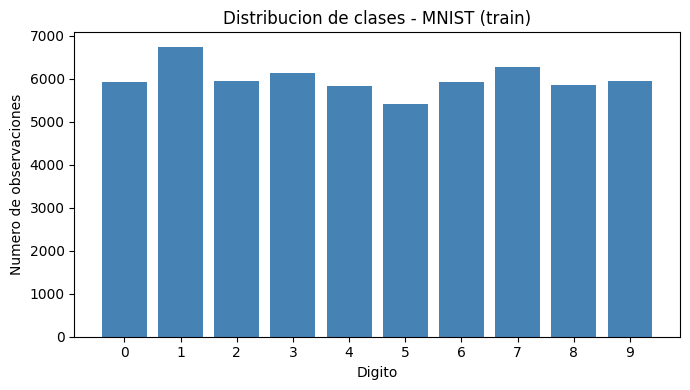

In [4]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(class_counts.index, class_counts.values, color="steelblue")
ax.set_xlabel("Digito")
ax.set_ylabel("Numero de observaciones")
ax.set_title("Distribucion de clases - MNIST (train)")
ax.set_xticks(range(10))
plt.tight_layout()
plt.show()


**Respuesta:** El dataset tiene **70,000 observaciones** en total: **60,000** en el split de entrenamiento y **10,000** en el de test, con **10 clases** (digitos 0-9). Las clases estan **razonablemente balanceadas**: cada digito tiene entre ~5,400 y ~6,900 observaciones en train, y la proporcion entre la clase menos y mas frecuente es de aproximadamente 0.81 (no es un desbalance severo que requiera tecnicas especiales como reponderacion u oversampling).

### ¿Cual es la dimension de cada imagen y que rango de valores tienen los pixeles?

In [5]:
sample_img, sample_label = raw_train_dataset[0]

print("Forma del tensor de una imagen:", sample_img.shape)
print("Tipo de dato:", sample_img.dtype)
print(f"Valor minimo de pixel: {sample_img.min().item():.4f}")
print(f"Valor maximo de pixel: {sample_img.max().item():.4f}")
print(f"Media de pixeles: {sample_img.mean().item():.4f}")

# Rango sobre TODO el dataset de train (no solo un ejemplo), tal como vienen originalmente (0-255 antes de ToTensor)
raw_pil, _ = raw_train_dataset.data, raw_train_dataset.targets
print()
print("Tensor crudo (antes de ToTensor), dataset.data:")
print("  shape:", raw_pil.shape, "dtype:", raw_pil.dtype)
print(f"  min={raw_pil.min().item()}, max={raw_pil.max().item()}")


Forma del tensor de una imagen: torch.Size([1, 28, 28])
Tipo de dato: torch.float32
Valor minimo de pixel: 0.0000
Valor maximo de pixel: 1.0000
Media de pixeles: 0.1377

Tensor crudo (antes de ToTensor), dataset.data:
  shape: torch.Size([60000, 28, 28]) dtype: torch.uint8
  min=0, max=255


**Respuesta:** Cada imagen tiene dimension **1x28x28** (1 canal, escala de grises, 28x28 pixeles). En su representacion cruda (`dataset.data`), los pixeles son enteros `uint8` en el rango **[0, 255]**. Al aplicar `transforms.ToTensor()`, PyTorch convierte la imagen a `float32` y **reescala automaticamente a [0, 1]** dividiendo entre 255.

### ¿Es necesario normalizar los valores de los pixeles?

**Respuesta:** Si. Aunque `ToTensor()` ya lleva los pixeles al rango [0, 1], es recomendable aplicar ademas una normalizacion tipo z-score (`transforms.Normalize`) usando la media y desviacion estandar del conjunto de entrenamiento. Esto centra los valores alrededor de 0, lo que ayuda a que el entrenamiento converja mas rapido y de forma mas estable (gradientes mejor escalados, especialmente relevante para capas con BatchNorm y para los pesos iniciales de las capas lineales/convolucionales). Calculamos la media y el std sobre train y los aplicamos tambien a validacion y test, sin recalcularlos en esos conjuntos.

In [6]:
# Media y std del dataset de train (en escala [0,1], luego de ToTensor) para Normalize
train_data_float = raw_train_dataset.data.float() / 255.0
MNIST_MEAN = train_data_float.mean().item()
MNIST_STD = train_data_float.std().item()
print(f"Media (train): {MNIST_MEAN:.4f}")
print(f"Std (train):   {MNIST_STD:.4f}")


Media (train): 0.1307
Std (train):   0.3081


### Visualizacion de ejemplos

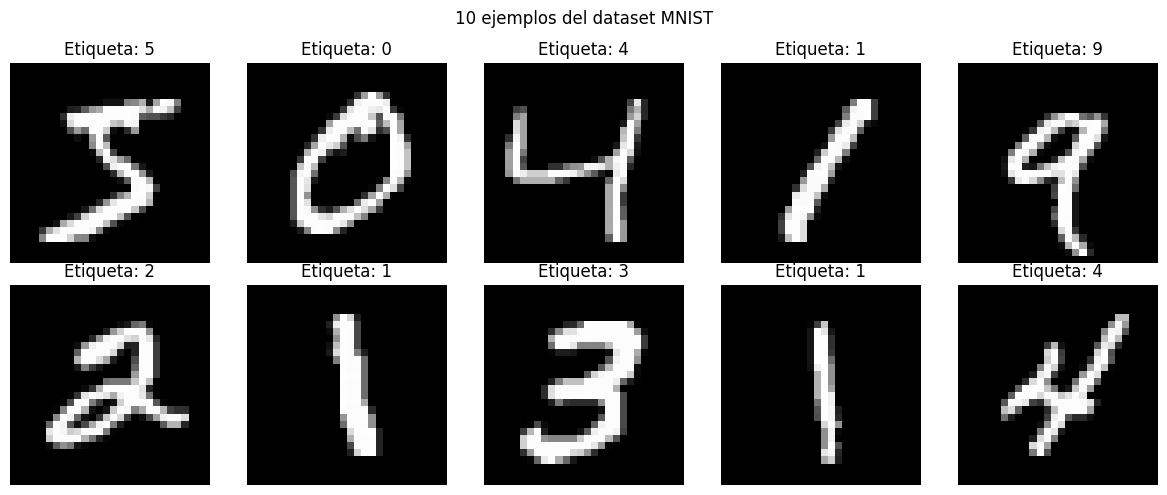

In [7]:
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.flatten()):
    img, label = raw_train_dataset[i]
    ax.imshow(img.squeeze(), cmap="gray")
    ax.set_title(f"Etiqueta: {label}")
    ax.axis("off")
plt.suptitle("10 ejemplos del dataset MNIST")
plt.tight_layout()
plt.show()


### Division en entrenamiento y validacion

El conjunto de test (10,000 imagenes) se deja completamente al margen hasta la evaluacion final. El conjunto de train (60,000 imagenes) se divide en **80% entrenamiento / 20% validacion**, y la validacion es la que guia la seleccion de hiperparametros y arquitectura.

Como MNIST es un dataset pequeno, en vez de aplicar `ToTensor()` + `Normalize()` imagen por imagen dentro del `DataLoader` (lo cual decodifica cada imagen como PIL y la transforma en cada acceso, generando overhead innecesario en cada epoch), convertimos el dataset completo a un unico tensor `float32` normalizado en memoria una sola vez, y construimos `TensorDataset`s sobre ese tensor. Esto es numericamente equivalente a `ToTensor()+Normalize()`, pero mucho mas rapido de iterar durante el entrenamiento.

In [8]:
def to_normalized_tensor(dataset):
    x = dataset.data.float().unsqueeze(1) / 255.0  # (N, 28, 28) -> (N, 1, 28, 28), escalado a [0, 1]
    x = (x - MNIST_MEAN) / MNIST_STD
    y = dataset.targets.long()
    return x, y


X_train_full, y_train_full = to_normalized_tensor(raw_train_dataset)
X_test, y_test = to_normalized_tensor(raw_test_dataset)

n_val = int(0.2 * len(X_train_full))
n_train_split = len(X_train_full) - n_val

generator = torch.Generator().manual_seed(RANDOM_STATE)
perm = torch.randperm(len(X_train_full), generator=generator)
train_idx, val_idx = perm[:n_train_split], perm[n_train_split:]

X_train, y_train = X_train_full[train_idx], y_train_full[train_idx]
X_val, y_val = X_train_full[val_idx], y_train_full[val_idx]

print(f"Train: {len(X_train)} | Val: {len(X_val)} | Test: {len(X_test)}")

BATCH_SIZE = 128
train_dataset = torch.utils.data.TensorDataset(X_train, y_train)
val_dataset = torch.utils.data.TensorDataset(X_val, y_val)
test_dataset = torch.utils.data.TensorDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)


Train: 48000 | Val: 12000 | Test: 10000


## 3. Investigacion: capas de PyTorch para la CNN

_(Seccion a completar con el detalle de la investigacion en el reporte LaTeX. A continuacion una instanciacion rapida de cada capa investigada, para verificar su comportamiento con un tensor de ejemplo.)_

In [9]:
# Tensor de ejemplo con la forma de un batch de MNIST: (batch, canales, alto, ancho)
example_batch = torch.randn(4, 1, 28, 28)

example_conv = nn.Conv2d(in_channels=1, out_channels=8, kernel_size=3, padding=1)
example_maxpool = nn.MaxPool2d(kernel_size=2)
example_avgpool = nn.AvgPool2d(kernel_size=2)
example_bn2d = nn.BatchNorm2d(num_features=8)
example_flatten = nn.Flatten()
example_ce_loss = nn.CrossEntropyLoss()

out = example_conv(example_batch)
print("Conv2d(1->8, k=3, pad=1):     ", example_batch.shape, "->", out.shape)

out_bn = example_bn2d(out)
print("BatchNorm2d(8):               ", out.shape, "->", out_bn.shape)

out_max = example_maxpool(out_bn)
print("MaxPool2d(k=2):               ", out_bn.shape, "->", out_max.shape)

out_avg = example_avgpool(out_bn)
print("AvgPool2d(k=2):               ", out_bn.shape, "->", out_avg.shape)

out_flat = example_flatten(out_max)
print("Flatten:                      ", out_max.shape, "->", out_flat.shape)

example_logits = torch.randn(4, 10)
example_targets = torch.tensor([1, 0, 4, 9])
print("CrossEntropyLoss(logits, y): ", example_ce_loss(example_logits, example_targets).item())


Conv2d(1->8, k=3, pad=1):      torch.Size([4, 1, 28, 28]) -> torch.Size([4, 8, 28, 28])
BatchNorm2d(8):                torch.Size([4, 8, 28, 28]) -> torch.Size([4, 8, 28, 28])
MaxPool2d(k=2):                torch.Size([4, 8, 28, 28]) -> torch.Size([4, 8, 14, 14])
AvgPool2d(k=2):                torch.Size([4, 8, 28, 28]) -> torch.Size([4, 8, 14, 14])
Flatten:                       torch.Size([4, 8, 14, 14]) -> torch.Size([4, 1568])
CrossEntropyLoss(logits, y):  2.3530516624450684


**Tensores, campo receptivo y parametros CNN vs. MLP** _(resumen breve, se ampliara en el reporte)_:

- **Tensor:** estructura de datos n-dimensional de PyTorch, analoga a un arreglo de NumPy pero con soporte para computo en GPU y diferenciacion automatica (`autograd`), sobre la cual se construyen todas las operaciones de una red neuronal.
- **Campo receptivo (receptive field):** la region de la imagen de entrada que influye en el valor de una unidad/neurona particular de una capa dada. Al apilar capas convolucionales (y pooling), el campo receptivo efectivo crece capa a capa, permitiendo que unidades profundas "vean" patrones mas grandes y globales de la imagen.
- **Menos parametros que un MLP equivalente:** una capa convolucional comparte los mismos pesos (el kernel) en todas las posiciones espaciales de la imagen, en lugar de tener una conexion (peso) independiente entre cada pixel de entrada y cada unidad de salida como en un MLP. Esto reduce drasticamente el numero de parametros y ademas introduce un sesgo util (equivarianza a traslacion): un mismo patron (borde, curva, etc.) se detecta igual sin importar en que parte de la imagen aparezca.


## 4. Definicion de las arquitecturas

Definimos dos clases parametrizables (`MLP` y `CNN`) para poder variar facilmente los hiperparametros de arquitectura entre iteraciones.

In [10]:
ACTIVATIONS = {
    "relu": nn.ReLU,
    "leaky_relu": nn.LeakyReLU,
}


class MLP(nn.Module):
    """MLP que recibe la imagen aplanada (28*28=784) como vector de entrada."""

    def __init__(self, input_dim=28 * 28, hidden_dims=(256, 128), num_classes=10,
                 activation="relu", dropout=0.0, use_batchnorm=False):
        super().__init__()
        activation_cls = ACTIVATIONS[activation]

        layers = [nn.Flatten()]
        prev_dim = input_dim
        for hidden_dim in hidden_dims:
            layers.append(nn.Linear(prev_dim, hidden_dim))
            if use_batchnorm:
                layers.append(nn.BatchNorm1d(hidden_dim))
            layers.append(activation_cls())
            if dropout > 0:
                layers.append(nn.Dropout(dropout))
            prev_dim = hidden_dim
        layers.append(nn.Linear(prev_dim, num_classes))

        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)


In [11]:
POOLINGS = {
    "max": nn.MaxPool2d,
    "avg": nn.AvgPool2d,
}


class CNN(nn.Module):
    """CNN que recibe la imagen como tensor 2D (1, 28, 28) y usa >=2 capas convolucionales.

    Cada bloque convolucional sigue el orden: Conv2d -> BatchNorm2d (opcional) -> ReLU -> Pool2d.
    Con 2 bloques de pooling (k=2) sobre una entrada de 28x28, el mapa de features final
    queda en 7x7 (28 -> 14 -> 7).
    """

    def __init__(self, conv_channels=(32, 64), kernel_size=3, pooling="max",
                 use_batchnorm=False, fc_hidden=128, dropout=0.0, num_classes=10):
        super().__init__()
        pool_cls = POOLINGS[pooling]
        padding = kernel_size // 2

        conv_layers = []
        in_channels = 1
        for out_channels in conv_channels:
            conv_layers.append(nn.Conv2d(in_channels, out_channels, kernel_size=kernel_size, padding=padding))
            if use_batchnorm:
                conv_layers.append(nn.BatchNorm2d(out_channels))
            conv_layers.append(nn.ReLU())
            conv_layers.append(pool_cls(kernel_size=2))
            in_channels = out_channels
        self.conv = nn.Sequential(*conv_layers)

        spatial_dim = 28 // (2 ** len(conv_channels))
        flat_dim = conv_channels[-1] * spatial_dim * spatial_dim

        fc_layers = [nn.Flatten(), nn.Linear(flat_dim, fc_hidden), nn.ReLU()]
        if dropout > 0:
            fc_layers.append(nn.Dropout(dropout))
        fc_layers.append(nn.Linear(fc_hidden, num_classes))
        self.fc = nn.Sequential(*fc_layers)

    def forward(self, x):
        x = self.conv(x)
        return self.fc(x)


In [12]:
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


# Prueba rapida: instanciar ambos modelos y correr un forward pass con un batch de train
test_mlp = MLP(hidden_dims=(256, 128), dropout=0.2, use_batchnorm=True)
test_cnn = CNN(conv_channels=(32, 64), kernel_size=3, pooling="max", use_batchnorm=True, dropout=0.2)

sample_x, sample_y = next(iter(train_loader))
print("Batch shape:", sample_x.shape)

print("\nMLP:")
print(test_mlp)
print("Output shape:", test_mlp(sample_x).shape, "| Parametros entrenables:", count_parameters(test_mlp))

print("\nCNN:")
print(test_cnn)
print("Output shape:", test_cnn(sample_x).shape, "| Parametros entrenables:", count_parameters(test_cnn))


Batch shape: torch.Size([128, 1, 28, 28])

MLP:
MLP(
  (net): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=256, bias=True)
    (2): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): ReLU()
    (4): Dropout(p=0.2, inplace=False)
    (5): Linear(in_features=256, out_features=128, bias=True)
    (6): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): ReLU()
    (8): Dropout(p=0.2, inplace=False)
    (9): Linear(in_features=128, out_features=10, bias=True)
  )
)
Output shape: torch.Size([128, 10]) | Parametros entrenables: 235914

CNN:
CNN(
  (conv): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3

## 5. Utilidades de entrenamiento y evaluacion

Definimos funciones genericas de entrenamiento y evaluacion que reutilizaremos en todas las iteraciones de ambas arquitecturas.

In [13]:
def build_optimizer(model, optimizer_name, lr, weight_decay=0.0):
    if optimizer_name == "adam":
        return optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    if optimizer_name == "sgd":
        return optim.SGD(model.parameters(), lr=lr, momentum=0.9, weight_decay=weight_decay)
    raise ValueError(f"Optimizador no soportado: {optimizer_name}")


@torch.no_grad()
def evaluate(model, loader, loss_fn):
    model.eval()
    running_loss, n_samples = 0.0, 0
    all_preds, all_targets = [], []

    for x, y in loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        logits = model(x)
        loss = loss_fn(logits, y)

        running_loss += loss.item() * x.size(0)
        n_samples += x.size(0)

        preds = logits.argmax(dim=1)
        all_preds.append(preds.cpu().numpy())
        all_targets.append(y.cpu().numpy())

    avg_loss = running_loss / n_samples
    y_pred = np.concatenate(all_preds)
    y_true = np.concatenate(all_targets)
    return avg_loss, y_true, y_pred


def classification_metrics(y_true, y_pred):
    accuracy = accuracy_score(y_true, y_pred)
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average="macro", zero_division=0
    )
    return {"accuracy": accuracy, "precision": precision, "recall": recall, "f1": f1}


def train_model(model, train_loader, val_loader, optimizer_name="adam", lr=1e-3,
                 weight_decay=0.0, epochs=8):
    model = model.to(DEVICE)
    optimizer = build_optimizer(model, optimizer_name, lr, weight_decay)
    loss_fn = nn.CrossEntropyLoss()

    history = {"train_loss": [], "val_loss": [], "val_accuracy": [],
               "val_precision": [], "val_recall": [], "val_f1": []}

    start_time = time.time()
    for _ in range(epochs):
        model.train()
        running_loss, n_samples = 0.0, 0
        for x, y in train_loader:
            x, y = x.to(DEVICE), y.to(DEVICE)

            optimizer.zero_grad()
            logits = model(x)
            loss = loss_fn(logits, y)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * x.size(0)
            n_samples += x.size(0)

        train_loss = running_loss / n_samples
        val_loss, y_true, y_pred = evaluate(model, val_loader, loss_fn)
        val_metrics = classification_metrics(y_true, y_pred)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["val_accuracy"].append(val_metrics["accuracy"])
        history["val_precision"].append(val_metrics["precision"])
        history["val_recall"].append(val_metrics["recall"])
        history["val_f1"].append(val_metrics["f1"])

    training_time = time.time() - start_time
    return history, training_time


## 6. Busqueda de hiperparametros - MLP

Partimos de una configuracion baseline y realizamos una busqueda dirigida: cada iteracion posterior cambia una o dos variables respecto a la anterior, para poder atribuir el efecto de cada cambio.

In [14]:
MLP_BASE = dict(hidden_dims=(128,), dropout=0.0, use_batchnorm=False,
                optimizer_name="adam", lr=1e-3, weight_decay=0.0, epochs=6)


def mlp_cfg(name, note, **overrides):
    c = {**MLP_BASE, **overrides, "name": name, "note": note}
    return c


mlp_configs = [
    mlp_cfg("M1", "Baseline (1 capa oculta de 128)"),
    mlp_cfg("M2", "Mas profunda/ancha (256, 128)", hidden_dims=(256, 128)),
    mlp_cfg("M3", "+ Dropout 0.3", hidden_dims=(256, 128), dropout=0.3),
    mlp_cfg("M4", "+ BatchNorm1d", hidden_dims=(256, 128), dropout=0.3, use_batchnorm=True),
    mlp_cfg("M5", "Learning rate alto (1e-2)", hidden_dims=(256, 128), dropout=0.3,
            use_batchnorm=True, lr=1e-2),
    mlp_cfg("M6", "Optimizador SGD+momentum", hidden_dims=(256, 128), dropout=0.3,
            use_batchnorm=True, optimizer_name="sgd", lr=1e-2),
]

for c in mlp_configs:
    print(c)


{'hidden_dims': (128,), 'dropout': 0.0, 'use_batchnorm': False, 'optimizer_name': 'adam', 'lr': 0.001, 'weight_decay': 0.0, 'epochs': 6, 'name': 'M1', 'note': 'Baseline (1 capa oculta de 128)'}
{'hidden_dims': (256, 128), 'dropout': 0.0, 'use_batchnorm': False, 'optimizer_name': 'adam', 'lr': 0.001, 'weight_decay': 0.0, 'epochs': 6, 'name': 'M2', 'note': 'Mas profunda/ancha (256, 128)'}
{'hidden_dims': (256, 128), 'dropout': 0.3, 'use_batchnorm': False, 'optimizer_name': 'adam', 'lr': 0.001, 'weight_decay': 0.0, 'epochs': 6, 'name': 'M3', 'note': '+ Dropout 0.3'}
{'hidden_dims': (256, 128), 'dropout': 0.3, 'use_batchnorm': True, 'optimizer_name': 'adam', 'lr': 0.001, 'weight_decay': 0.0, 'epochs': 6, 'name': 'M4', 'note': '+ BatchNorm1d'}
{'hidden_dims': (256, 128), 'dropout': 0.3, 'use_batchnorm': True, 'optimizer_name': 'adam', 'lr': 0.01, 'weight_decay': 0.0, 'epochs': 6, 'name': 'M5', 'note': 'Learning rate alto (1e-2)'}
{'hidden_dims': (256, 128), 'dropout': 0.3, 'use_batchnorm': 

In [15]:
mlp_histories = {}
mlp_models = {}
mlp_results = []

for c in mlp_configs:
    torch.manual_seed(RANDOM_STATE)
    model = MLP(hidden_dims=c["hidden_dims"], dropout=c["dropout"], use_batchnorm=c["use_batchnorm"])
    n_params = count_parameters(model)

    history, training_time = train_model(
        model, train_loader, val_loader,
        optimizer_name=c["optimizer_name"], lr=c["lr"], weight_decay=c["weight_decay"], epochs=c["epochs"],
    )

    mlp_histories[c["name"]] = history
    mlp_models[c["name"]] = model

    mlp_results.append({
        "#": c["name"],
        "Nota": c["note"],
        "hidden_dims": c["hidden_dims"],
        "dropout": c["dropout"],
        "batchnorm": c["use_batchnorm"],
        "optimizer": c["optimizer_name"],
        "lr": c["lr"],
        "epochs": c["epochs"],
        "Parametros": n_params,
        "Train loss (final)": history["train_loss"][-1],
        "Val loss (final)": history["val_loss"][-1],
        "Val accuracy": history["val_accuracy"][-1],
        "Val precision": history["val_precision"][-1],
        "Val recall": history["val_recall"][-1],
        "Val F1": history["val_f1"][-1],
        "Tiempo (s)": training_time,
    })

    print(f"{c['name']} listo | val_acc={history['val_accuracy'][-1]:.4f} | "
          f"val_f1={history['val_f1'][-1]:.4f} | params={n_params} | tiempo={training_time:.1f}s")


M1 listo | val_acc=0.9731 | val_f1=0.9728 | params=101770 | tiempo=10.6s


M2 listo | val_acc=0.9743 | val_f1=0.9741 | params=235146 | tiempo=17.5s


M3 listo | val_acc=0.9736 | val_f1=0.9734 | params=235146 | tiempo=17.3s


M4 listo | val_acc=0.9758 | val_f1=0.9757 | params=235914 | tiempo=18.6s


M5 listo | val_acc=0.9749 | val_f1=0.9747 | params=235914 | tiempo=16.5s


M6 listo | val_acc=0.9732 | val_f1=0.9731 | params=235914 | tiempo=17.2s


### Tabla de resultados - iteraciones MLP

In [16]:
mlp_results_df = pd.DataFrame(mlp_results).sort_values("Val F1", ascending=False).reset_index(drop=True)
mlp_results_df


,#,Nota,hidden_dims,dropout,batchnorm,optimizer,lr,epochs,Parametros,Train loss (final),Val loss (final),Val accuracy,Val precision,Val recall,Val F1,Tiempo (s)
0,M4,+ BatchNorm1d,"(256, 128)",0.3,True,adam,0.001,6,235914,0.079522,0.077278,0.975833,0.976086,0.975463,0.975675,18.645601
1,M5,Learning rate alto (1e-2),"(256, 128)",0.3,True,adam,0.010,6,235914,0.082954,0.082185,0.974917,0.974756,0.974804,0.974716,16.533948
2,M2,"Mas profunda/ancha (256, 128)","(256, 128)",0.0,False,adam,0.001,6,235146,0.035002,0.089505,0.974333,0.973973,0.974330,0.974087,17.477014
3,M3,+ Dropout 0.3,"(256, 128)",0.3,False,adam,0.001,6,235146,0.083452,0.084567,0.973583,0.973311,0.973561,0.973384,17.291915
4,M6,Optimizador SGD+momentum,"(256, 128)",0.3,True,sgd,0.010,6,235914,0.102108,0.085056,0.973250,0.973380,0.972881,0.973063,17.183608
5,M1,Baseline (1 capa oculta de 128),"(128,)",0.0,False,adam,0.001,6,101770,0.050448,0.090146,0.973083,0.972800,0.972986,0.972845,10.554524


### Curvas de perdida - MLP

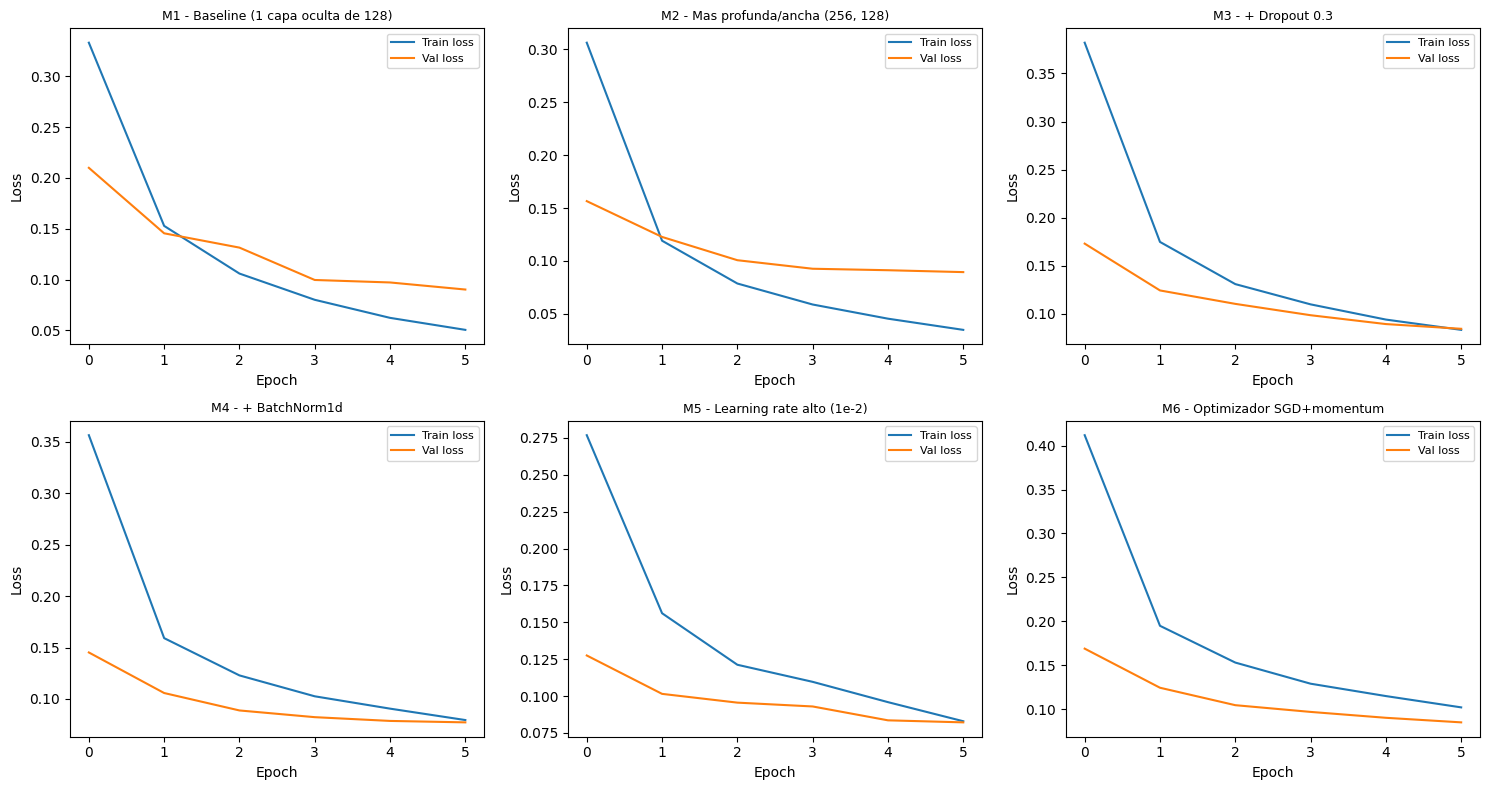

In [17]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, c in zip(axes.flatten(), mlp_configs):
    h = mlp_histories[c["name"]]
    ax.plot(h["train_loss"], label="Train loss")
    ax.plot(h["val_loss"], label="Val loss")
    ax.set_title(f"{c['name']} - {c['note']}", fontsize=9)
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()


## 7. Busqueda de hiperparametros - CNN

Misma estrategia: baseline y cambios de una o dos variables a la vez (numero de filtros, batchnorm, dropout, tipo de pooling, tamano de kernel).

In [18]:
CNN_BASE = dict(conv_channels=(16, 32), kernel_size=3, pooling="max", use_batchnorm=False,
                fc_hidden=128, dropout=0.0, optimizer_name="adam", lr=1e-3, weight_decay=0.0, epochs=6)


def cnn_cfg(name, note, **overrides):
    c = {**CNN_BASE, **overrides, "name": name, "note": note}
    return c


# Nota sobre el diseno de esta busqueda: al no contar con GPU en esta maquina (torch.cuda.is_available()
# es False), las capas convolucionales son el cuello de botella de computo. Se uso (16, 32) como
# baseline y solo se sube a (32, 64) en la iteracion C2 para medir el efecto de "mas filtros" sin que
# el resto de iteraciones (BatchNorm, Dropout, pooling, kernel) hereden ese costo extra.
cnn_configs = [
    cnn_cfg("C1", "Baseline (16, 32 filtros)"),
    cnn_cfg("C2", "Mas filtros (32, 64)", conv_channels=(32, 64)),
    cnn_cfg("C3", "+ BatchNorm2d", use_batchnorm=True),
    cnn_cfg("C4", "+ Dropout 0.3", use_batchnorm=True, dropout=0.3),
    cnn_cfg("C5", "AvgPool2d en vez de MaxPool2d", use_batchnorm=True, dropout=0.3, pooling="avg"),
    cnn_cfg("C6", "Kernel mas grande (5x5)", use_batchnorm=True, dropout=0.3, kernel_size=5),
]

for c in cnn_configs:
    print(c)


{'conv_channels': (16, 32), 'kernel_size': 3, 'pooling': 'max', 'use_batchnorm': False, 'fc_hidden': 128, 'dropout': 0.0, 'optimizer_name': 'adam', 'lr': 0.001, 'weight_decay': 0.0, 'epochs': 6, 'name': 'C1', 'note': 'Baseline (16, 32 filtros)'}
{'conv_channels': (32, 64), 'kernel_size': 3, 'pooling': 'max', 'use_batchnorm': False, 'fc_hidden': 128, 'dropout': 0.0, 'optimizer_name': 'adam', 'lr': 0.001, 'weight_decay': 0.0, 'epochs': 6, 'name': 'C2', 'note': 'Mas filtros (32, 64)'}
{'conv_channels': (16, 32), 'kernel_size': 3, 'pooling': 'max', 'use_batchnorm': True, 'fc_hidden': 128, 'dropout': 0.0, 'optimizer_name': 'adam', 'lr': 0.001, 'weight_decay': 0.0, 'epochs': 6, 'name': 'C3', 'note': '+ BatchNorm2d'}
{'conv_channels': (16, 32), 'kernel_size': 3, 'pooling': 'max', 'use_batchnorm': True, 'fc_hidden': 128, 'dropout': 0.3, 'optimizer_name': 'adam', 'lr': 0.001, 'weight_decay': 0.0, 'epochs': 6, 'name': 'C4', 'note': '+ Dropout 0.3'}
{'conv_channels': (16, 32), 'kernel_size': 3, '

In [19]:
cnn_histories = {}
cnn_models = {}
cnn_results = []

for c in cnn_configs:
    torch.manual_seed(RANDOM_STATE)
    model = CNN(conv_channels=c["conv_channels"], kernel_size=c["kernel_size"], pooling=c["pooling"],
                use_batchnorm=c["use_batchnorm"], fc_hidden=c["fc_hidden"], dropout=c["dropout"])
    n_params = count_parameters(model)

    history, training_time = train_model(
        model, train_loader, val_loader,
        optimizer_name=c["optimizer_name"], lr=c["lr"], weight_decay=c["weight_decay"], epochs=c["epochs"],
    )

    cnn_histories[c["name"]] = history
    cnn_models[c["name"]] = model

    cnn_results.append({
        "#": c["name"],
        "Nota": c["note"],
        "conv_channels": c["conv_channels"],
        "kernel_size": c["kernel_size"],
        "pooling": c["pooling"],
        "batchnorm": c["use_batchnorm"],
        "dropout": c["dropout"],
        "lr": c["lr"],
        "epochs": c["epochs"],
        "Parametros": n_params,
        "Train loss (final)": history["train_loss"][-1],
        "Val loss (final)": history["val_loss"][-1],
        "Val accuracy": history["val_accuracy"][-1],
        "Val precision": history["val_precision"][-1],
        "Val recall": history["val_recall"][-1],
        "Val F1": history["val_f1"][-1],
        "Tiempo (s)": training_time,
    })

    print(f"{c['name']} listo | val_acc={history['val_accuracy'][-1]:.4f} | "
          f"val_f1={history['val_f1'][-1]:.4f} | params={n_params} | tiempo={training_time:.1f}s")


C1 listo | val_acc=0.9875 | val_f1=0.9874 | params=206922 | tiempo=125.2s


C2 listo | val_acc=0.9882 | val_f1=0.9881 | params=421642 | tiempo=241.1s


C3 listo | val_acc=0.9868 | val_f1=0.9866 | params=207018 | tiempo=134.6s


C4 listo | val_acc=0.9879 | val_f1=0.9879 | params=207018 | tiempo=133.8s


C5 listo | val_acc=0.9892 | val_f1=0.9891 | params=207018 | tiempo=125.1s


C6 listo | val_acc=0.9888 | val_f1=0.9887 | params=215466 | tiempo=166.0s


### Tabla de resultados - iteraciones CNN

In [20]:
cnn_results_df = pd.DataFrame(cnn_results).sort_values("Val F1", ascending=False).reset_index(drop=True)
cnn_results_df


,#,Nota,conv_channels,kernel_size,pooling,batchnorm,dropout,lr,epochs,Parametros,Train loss (final),Val loss (final),Val accuracy,Val precision,Val recall,Val F1,Tiempo (s)
0,C5,AvgPool2d en vez de MaxPool2d,"(16, 32)",3,avg,True,0.3,0.001,6,207018,0.036184,0.040405,0.989167,0.989204,0.989070,0.989114,125.106715
1,C6,Kernel mas grande (5x5),"(16, 32)",5,max,True,0.3,0.001,6,215466,0.031384,0.038378,0.988750,0.988776,0.988691,0.988700,165.983634
2,C2,"Mas filtros (32, 64)","(32, 64)",3,max,False,0.0,0.001,6,421642,0.016322,0.043677,0.988167,0.988145,0.988093,0.988094,241.115271
3,C4,+ Dropout 0.3,"(16, 32)",3,max,True,0.3,0.001,6,207018,0.035559,0.041702,0.987917,0.988027,0.987743,0.987858,133.819853
4,C1,"Baseline (16, 32 filtros)","(16, 32)",3,max,False,0.0,0.001,6,206922,0.021449,0.039873,0.987500,0.987366,0.987462,0.987402,125.188790
5,C3,+ BatchNorm2d,"(16, 32)",3,max,True,0.0,0.001,6,207018,0.021167,0.042962,0.986750,0.986525,0.986737,0.986593,134.621162


### Curvas de perdida - CNN

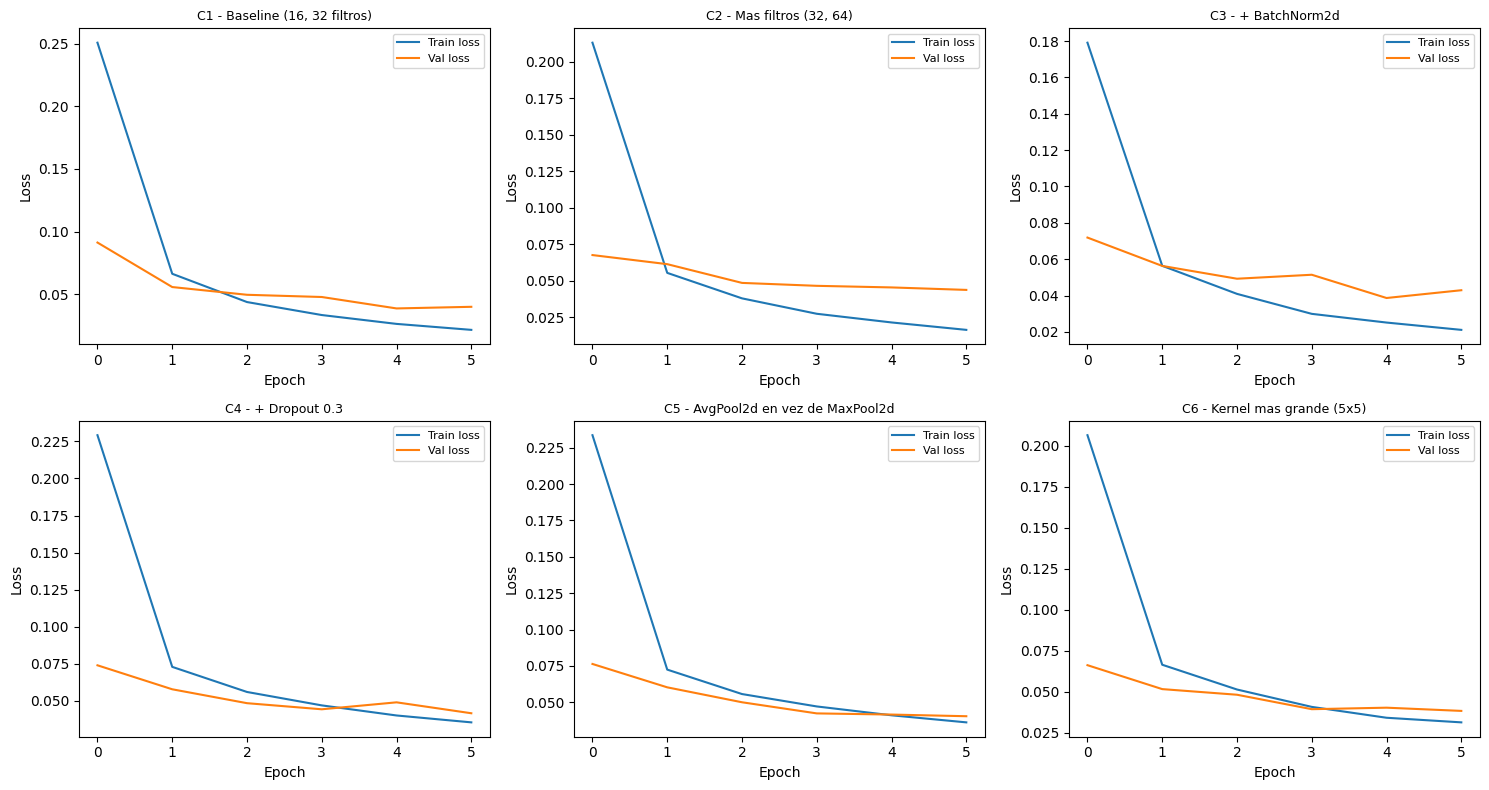

In [21]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, c in zip(axes.flatten(), cnn_configs):
    h = cnn_histories[c["name"]]
    ax.plot(h["train_loss"], label="Train loss")
    ax.plot(h["val_loss"], label="Val loss")
    ax.set_title(f"{c['name']} - {c['note']}", fontsize=9)
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()


## 8. Seleccion de mejores modelos y evaluacion final sobre test

Seleccionamos la mejor configuracion de cada arquitectura segun su **F1 macro de validacion**, y evaluamos ambos modelos **una unica vez** sobre el conjunto de test.

In [22]:
best_mlp_name = mlp_results_df.iloc[0]["#"]
best_cnn_name = cnn_results_df.iloc[0]["#"]

best_mlp_model = mlp_models[best_mlp_name]
best_cnn_model = cnn_models[best_cnn_name]

print(f"Mejor MLP segun val F1: {best_mlp_name}")
print(f"Mejor CNN segun val F1: {best_cnn_name}")

loss_fn = nn.CrossEntropyLoss()

test_loss_mlp, y_true_mlp, y_pred_mlp = evaluate(best_mlp_model, test_loader, loss_fn)
test_metrics_mlp = classification_metrics(y_true_mlp, y_pred_mlp)

test_loss_cnn, y_true_cnn, y_pred_cnn = evaluate(best_cnn_model, test_loader, loss_fn)
test_metrics_cnn = classification_metrics(y_true_cnn, y_pred_cnn)

print("\nMLP - metricas finales sobre TEST:")
print(f"  Loss: {test_loss_mlp:.4f}")
for k, v in test_metrics_mlp.items():
    print(f"  {k}: {v:.4f}")

print("\nCNN - metricas finales sobre TEST:")
print(f"  Loss: {test_loss_cnn:.4f}")
for k, v in test_metrics_cnn.items():
    print(f"  {k}: {v:.4f}")


Mejor MLP segun val F1: M4
Mejor CNN segun val F1: C5



MLP - metricas finales sobre TEST:
  Loss: 0.0688
  accuracy: 0.9796
  precision: 0.9797
  recall: 0.9794
  f1: 0.9795

CNN - metricas finales sobre TEST:
  Loss: 0.0353
  accuracy: 0.9886
  precision: 0.9886
  recall: 0.9885
  f1: 0.9885


### Matrices de confusion

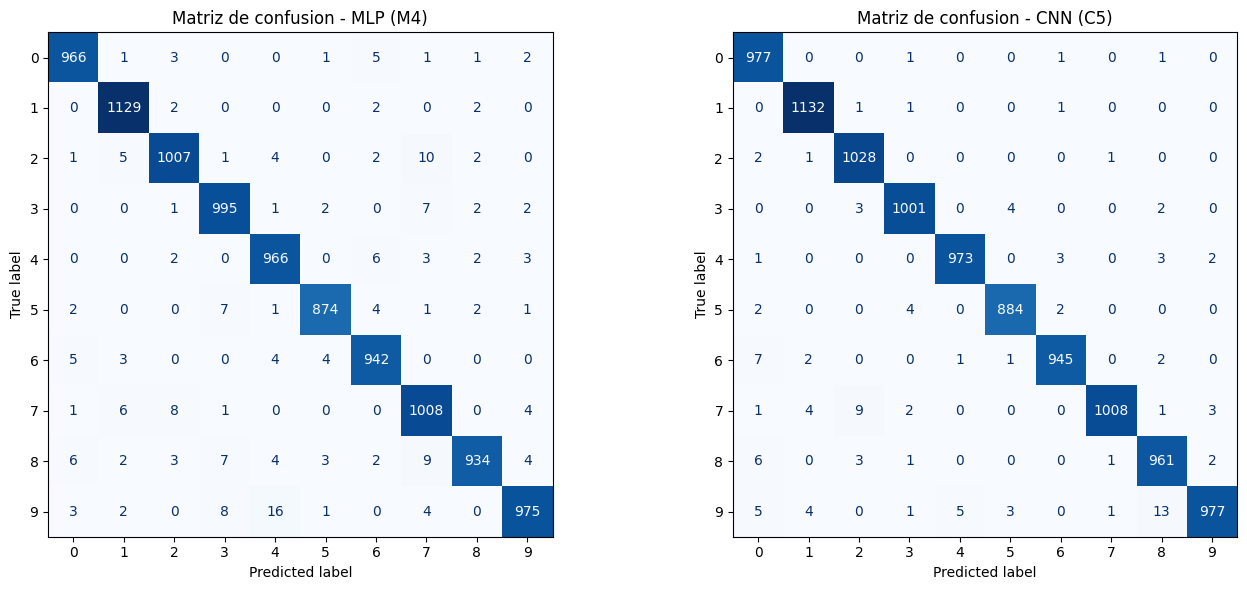

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

cm_mlp = confusion_matrix(y_true_mlp, y_pred_mlp)
ConfusionMatrixDisplay(cm_mlp, display_labels=range(10)).plot(ax=axes[0], colorbar=False, cmap="Blues")
axes[0].set_title(f"Matriz de confusion - MLP ({best_mlp_name})")

cm_cnn = confusion_matrix(y_true_cnn, y_pred_cnn)
ConfusionMatrixDisplay(cm_cnn, display_labels=range(10)).plot(ax=axes[1], colorbar=False, cmap="Blues")
axes[1].set_title(f"Matriz de confusion - CNN ({best_cnn_name})")

plt.tight_layout()
plt.show()


## 9. Comparacion de arquitecturas

In [24]:
mlp_row = mlp_results_df[mlp_results_df["#"] == best_mlp_name].iloc[0]
cnn_row = cnn_results_df[cnn_results_df["#"] == best_cnn_name].iloc[0]

comparison_df = pd.DataFrame([
    {
        "Arquitectura": "MLP",
        "Config": best_mlp_name,
        "Parametros": mlp_row["Parametros"],
        "Tiempo entrenamiento (s)": mlp_row["Tiempo (s)"],
        "Test accuracy": test_metrics_mlp["accuracy"],
        "Test precision": test_metrics_mlp["precision"],
        "Test recall": test_metrics_mlp["recall"],
        "Test F1": test_metrics_mlp["f1"],
    },
    {
        "Arquitectura": "CNN",
        "Config": best_cnn_name,
        "Parametros": cnn_row["Parametros"],
        "Tiempo entrenamiento (s)": cnn_row["Tiempo (s)"],
        "Test accuracy": test_metrics_cnn["accuracy"],
        "Test precision": test_metrics_cnn["precision"],
        "Test recall": test_metrics_cnn["recall"],
        "Test F1": test_metrics_cnn["f1"],
    },
])
comparison_df


,Arquitectura,Config,Parametros,Tiempo entrenamiento (s),Test accuracy,Test precision,Test recall,Test F1
0,MLP,M4,235914,18.645601,0.9796,0.979739,0.979396,0.979519
1,CNN,C5,207018,125.106715,0.9886,0.988627,0.988529,0.988537


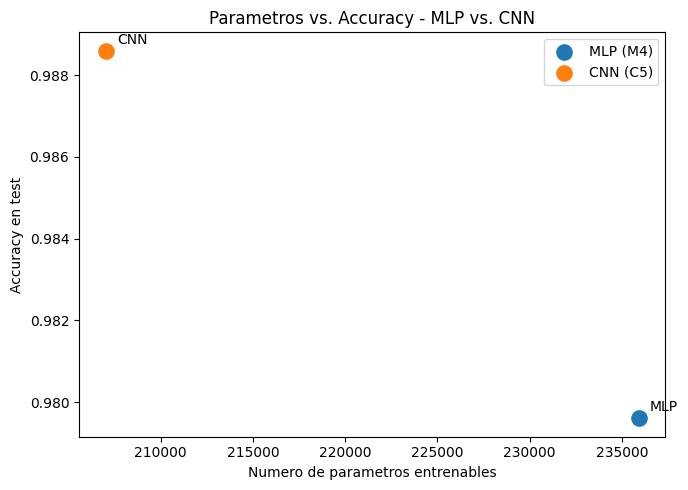

In [25]:
fig, ax = plt.subplots(figsize=(7, 5))
for _, row in comparison_df.iterrows():
    ax.scatter(row["Parametros"], row["Test accuracy"], s=120, label=f"{row['Arquitectura']} ({row['Config']})")
    ax.annotate(row["Arquitectura"], (row["Parametros"], row["Test accuracy"]),
                textcoords="offset points", xytext=(8, 5))
ax.set_xlabel("Numero de parametros entrenables")
ax.set_ylabel("Accuracy en test")
ax.set_title("Parametros vs. Accuracy - MLP vs. CNN")
ax.legend()
plt.tight_layout()
plt.show()


## 10. Guardado de resultados

Guardamos las tablas de resultados en CSV para poder referenciarlas desde el reporte.

In [26]:
all_results_df = pd.concat([mlp_results_df, cnn_results_df], ignore_index=True)
all_results_df.to_csv("iteraciones_resumen.csv", index=False)
comparison_df.to_csv("comparacion_arquitecturas.csv", index=False)

print("Tablas guardadas: iteraciones_resumen.csv, comparacion_arquitecturas.csv")


Tablas guardadas: iteraciones_resumen.csv, comparacion_arquitecturas.csv


## 11. Discusion y analisis

_(Seccion a completar en el reporte LaTeX, con base en los resultados obtenidos arriba.)_